# Batch calibratie van decay-bestanden

Dit notebook verwerkt **meerdere `.h5m`-bestanden** achter elkaar, voert voor elk bestand een **3-staps calibratie** uit:

1. **Coarse search**
2. **Tussenstap / medium search**
3. **Fine search**

Per bestand krijg je:
- de beste lineaire en quadratische dampingcoëfficiënten
- de score van elke zoekstap
- een plot van de **best gecalibreerde simulatie** versus experiment
- een samenvattende tabel aan het einde

> Let op: dit notebook gaat uit van dezelfde modelopzet en signaalnamen als in je originele notebook.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py
import OrcFxAPI

from pathlib import Path
from scipy.signal import find_peaks

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True


## Instellingen

Kies hieronder:
- het OrcaFlex-model
- één map of een expliciete lijst met `.h5m`-bestanden
- de ranges voor coarse / tussenstap / fine


In [2]:

# =========================
# PADEN
# =========================
model_path = r"c:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_ORCA\Decay_opzet_fixed_fine.dat"

# Optie A: expliciete lijst
exp_paths = [
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_007_01_Decay1.h5m",
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_008_01_Decay1.h5m",
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_009_01_Decay1.h5m",
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_010_01_Decay1.h5m",
    r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_011_01_Decay1.h5m",
]

# Optie B: automatisch meerdere bestanden uit dezelfde map ophalen
# Laat use_glob = True om onderstaande pattern te gebruiken.
use_glob = False
exp_glob_pattern = r"C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\*.h5m"

# =========================
# PLOT / FIT SETTINGS
# =========================
LABEL_SIZE = 14
TICK_SIZE = 12
TITLE_SIZE = 16

lookback_window = 5.0
quiet_window_end = 12.0
quiet_window_length = 50.0

n = 8  # aantal extrema inclusief startpunt

# =========================
# COARSE / TUSSENSTAP / FINE
# =========================
coarse_lin_values = np.linspace(0, 15, 7)
coarse_quad_values = np.linspace(0, 15, 7)

mid_delta_lin = 2.5
mid_delta_quad = 2.5
mid_num_lin = 9
mid_num_quad = 9

fine_delta_lin = 0.75
fine_delta_quad = 0.75
fine_num_lin = 11
fine_num_quad = 11

# =========================
# OPSLAAN VAN PLOTS
# =========================
save_plots = False
plot_output_dir = Path("batch_decay_plots")


In [3]:

def resolve_exp_paths(exp_paths, use_glob=False, exp_glob_pattern=None):
    if use_glob:
        if not exp_glob_pattern:
            raise ValueError("use_glob=True maar geen exp_glob_pattern opgegeven.")
        paths = sorted(str(p) for p in Path(exp_glob_pattern).parent.glob(Path(exp_glob_pattern).name))
    else:
        paths = [str(Path(p)) for p in exp_paths]

    paths = [p for p in paths if Path(p).suffix.lower() == ".h5m"]

    if not paths:
        raise ValueError("Geen .h5m-bestanden gevonden.")

    return paths


all_exp_paths = resolve_exp_paths(exp_paths, use_glob=use_glob, exp_glob_pattern=exp_glob_pattern)
print(f"Aantal bestanden gevonden: {len(all_exp_paths)}")
for p in all_exp_paths:
    print(" -", p)


Aantal bestanden gevonden: 5
 - C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_007_01_Decay1.h5m
 - C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_008_01_Decay1.h5m
 - C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_009_01_Decay1.h5m
 - C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_010_01_Decay1.h5m
 - C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_011_01_Decay1.h5m


## Helperfuncties

In [4]:

def load_experiment_data(exp_path):
    with h5py.File(exp_path, "r") as f:
        t_filt = f["FittedSignals/time"][:]
        z_filt = f["FittedSignals/Z_COG decay fit"][:]

        t_unfiltered = f["UnfilteredSignals/time"][:]
        z_unfiltered = f["UnfilteredSignals/Z_COG (unfiltered)"][:]

    return t_filt, z_filt, t_unfiltered, z_unfiltered


def extract_decay_from_file(
    exp_path,
    lookback_window=5.0,
    quiet_window_end=12.0,
    quiet_window_length=50.0,
):
    t_filt, z_filt, t_unfiltered, z_unfiltered = load_experiment_data(exp_path)

    # 1. decay-start schatting uit filtered signal
    t_decay_start_guess = t_filt[0]

    # 2. rustige periode in ongefilterd signaal
    quiet_start = t_decay_start_guess - quiet_window_end - quiet_window_length
    quiet_end = t_decay_start_guess - quiet_window_end
    mask_quiet = (t_unfiltered >= quiet_start) & (t_unfiltered <= quiet_end)

    if not np.any(mask_quiet):
        raise ValueError(f"Geen data gevonden in rustige periode voor {exp_path}")

    z_eq = np.mean(z_unfiltered[mask_quiet])

    # 3. initiële amplitude in ongefilterd signaal
    search_start = t_decay_start_guess - lookback_window
    search_end = t_decay_start_guess
    mask_search = (t_unfiltered >= search_start) & (t_unfiltered <= search_end)

    if not np.any(mask_search):
        raise ValueError(f"Geen data gevonden in zoekvenster vóór decay-start voor {exp_path}")

    t_search = t_unfiltered[mask_search]
    z_search = z_unfiltered[mask_search]

    deviation = z_search - z_eq
    idx_local = np.argmax(np.abs(deviation))

    t_init = t_search[idx_local]
    z_init = z_search[idx_local]
    A0_signed = z_init - z_eq
    A0 = np.abs(A0_signed)

    # 4. eerste piek/dal in filtered signaal na t_init
    mask_after_init = t_filt > t_init
    t_after = t_filt[mask_after_init]
    z_after = z_filt[mask_after_init]

    if len(t_after) == 0:
        raise ValueError(f"Geen gefilterde data gevonden na t_init voor {exp_path}")

    if A0_signed >= 0:
        peaks, _ = find_peaks(z_after)
    else:
        peaks, _ = find_peaks(-z_after)

    if len(peaks) == 0:
        raise ValueError(f"Geen pieken/dalen gevonden in gefilterd signaal voor {exp_path}")

    idx_first_peak_local = peaks[0]
    t_decay_start = t_after[idx_first_peak_local]
    z_decay_start = z_after[idx_first_peak_local]

    # 4b. bepaal welk extremum-nummer dit is sinds t_init in ongefilterd signaal
    mask_between = (t_unfiltered > t_init) & (t_unfiltered <= t_decay_start)
    t_between = t_unfiltered[mask_between]
    z_between = z_unfiltered[mask_between]

    if A0_signed >= 0:
        extrema_between, _ = find_peaks(z_between)
    else:
        extrema_between, _ = find_peaks(-z_between)

    extremum_number = len(extrema_between)
    if extremum_number < 1:
        extremum_number = 1

    # 5. decay-signaal vanaf decay-start
    mask_decay = t_filt >= t_decay_start
    t_decay = t_filt[mask_decay] - t_decay_start
    z_decay = z_filt[mask_decay] - z_eq

    fit_positive = A0_signed >= 0
    prom = 0.01 * abs(z_decay[0]) if len(z_decay) > 0 and abs(z_decay[0]) > 0 else None
    ref_delay = t_decay_start - t_init

    return {
        "exp_path": exp_path,
        "t_filt": t_filt,
        "z_filt": z_filt,
        "t_unfiltered": t_unfiltered,
        "z_unfiltered": z_unfiltered,
        "z_eq": z_eq,
        "t_init": t_init,
        "z_init": z_init,
        "A0": A0,
        "A0_signed": A0_signed,
        "t_decay_start": t_decay_start,
        "z_decay_start": z_decay_start,
        "t_decay": t_decay,
        "z_decay": z_decay,
        "fit_positive": fit_positive,
        "prom": prom,
        "ref_delay": ref_delay,
        "extremum_number": extremum_number,
        "quiet_start": quiet_start,
        "quiet_end": quiet_end,
        "search_start": search_start,
        "search_end": search_end,
    }


def shift_signal_to_first_extremum_after_start(t, z, positive=True, prominence=None, extremum_number=1):
    t = np.asarray(t)
    z = np.asarray(z)

    if len(t) < 2:
        raise ValueError("Signaal is te kort.")

    z_rest = z[1:]

    peak_kwargs = {}
    if prominence is not None:
        peak_kwargs["prominence"] = prominence

    if positive:
        idx_local, _ = find_peaks(z_rest, **peak_kwargs)
    else:
        idx_local, _ = find_peaks(-z_rest, **peak_kwargs)

    if len(idx_local) < extremum_number:
        raise ValueError(
            f"Niet genoeg extrema gevonden na start. "
            f"Gevraagd: {extremum_number}, gevonden: {len(idx_local)}"
        )

    idx_pick = idx_local[extremum_number - 1] + 1
    t_shift = t[idx_pick:] - t[idx_pick]
    z_shift = z[idx_pick:]

    return t_shift, z_shift, idx_pick


def get_n_extrema_including_start(t, z, n=8, positive=True, prominence=None):
    t = np.asarray(t)
    z = np.asarray(z)

    if len(t) == 0:
        raise ValueError("Leeg signaal.")
    if n < 1:
        raise ValueError("n moet minstens 1 zijn.")

    t_ext = [t[0]]
    z_ext = [z[0]]

    if n == 1:
        return np.array(t_ext), np.array(z_ext)

    t_rest = t[1:]
    z_rest = z[1:]

    peak_kwargs = {}
    if prominence is not None:
        peak_kwargs["prominence"] = prominence

    if positive:
        idx, _ = find_peaks(z_rest, **peak_kwargs)
    else:
        idx, _ = find_peaks(-z_rest, **peak_kwargs)

    if len(idx) < n - 1:
        raise ValueError(f"Te weinig extrema gevonden: {len(idx)+1} incl. start, {n} nodig.")

    idx = idx[:n - 1]

    t_ext.extend(t_rest[idx])
    z_ext.extend(z_rest[idx])

    return np.array(t_ext), np.array(z_ext)



def compute_extrema_nrmse(z_sim_troughs, z_exp_troughs, z_sim_peaks, z_exp_peaks):
    z_sim_peaks = np.asarray(z_sim_peaks, dtype=float)
    z_exp_peaks = np.asarray(z_exp_peaks, dtype=float)
    z_sim_troughs = np.asarray(z_sim_troughs, dtype=float)
    z_exp_troughs = np.asarray(z_exp_troughs, dtype=float)

    n_peaks = min(len(z_sim_peaks), len(z_exp_peaks))
    n_troughs = min(len(z_sim_troughs), len(z_exp_troughs))

    if n_peaks == 0:
        raise ValueError("Geen overeenkomstige pieken gevonden voor de score.")
    if n_troughs == 0:
        raise ValueError("Geen overeenkomstige dalen gevonden voor de score.")

    z_sim_peaks = z_sim_peaks[:n_peaks]
    z_exp_peaks = z_exp_peaks[:n_peaks]
    z_sim_troughs = z_sim_troughs[:n_troughs]
    z_exp_troughs = z_exp_troughs[:n_troughs]

    def compute_nrmse(sim, exp):
        scale = max(np.max(np.abs(exp)), 1e-6)
        return np.sqrt(np.mean((sim - exp) ** 2)) / scale

    nrmse_peaks = compute_nrmse(z_sim_peaks, z_exp_peaks)
    nrmse_troughs = compute_nrmse(z_sim_troughs, z_exp_troughs)

    total_score = 0.5 * (nrmse_peaks + nrmse_troughs)

    return {
        "score": total_score,
        "nrmse_peaks": nrmse_peaks,
        "nrmse_troughs": nrmse_troughs,
        "n_peaks_used": n_peaks,
        "n_troughs_used": n_troughs,
    }


def compute_period(signal_t, signal_z, positive=True, prominence=0.01):
    if positive:
        idx, _ = find_peaks(signal_z, prominence=prominence)
    else:
        idx, _ = find_peaks(-signal_z, prominence=prominence)

    if len(idx) < 2:
        return np.nan, idx

    periods = np.diff(signal_t[idx])
    return np.mean(periods), idx


In [5]:

def run_decay_simulation(c_lin, c_quad, A0_signed, model_path):
    model = OrcFxAPI.Model(model_path)
    constraint = model["decay_constraint"]
    floaters = model["floaters"]
    floatertype = model["Floatertype"]

    floatertype.OtherDampingLinearCoeffz = c_lin
    floatertype.OtherDampingQuadraticCoeffz = c_quad

    # Zelfde aanname als je originele notebook:
    constraint.InFrameInitialZ = A0_signed

    model.RunSimulation()

    t_sim = np.array(model.general.TimeHistory("Time"))
    z_sim_raw = np.array(floaters.TimeHistory("Z"))

    n_tail = min(100, len(z_sim_raw))
    z_eq_sim = np.mean(z_sim_raw[-n_tail:])
    z_sim = z_sim_raw - z_eq_sim
    t_sim = t_sim - t_sim[0]

    return t_sim, z_sim


In [6]:
def evaluate_candidate(c_lin, c_quad, exp_info, n, model_path):
    t_sim, z_sim = run_decay_simulation(
        c_lin=c_lin,
        c_quad=c_quad,
        A0_signed=exp_info["A0_signed"],
        model_path=model_path,
    )

    t_sim_shift, z_sim_shift, idx_pick = shift_signal_to_first_extremum_after_start(
        t_sim,
        z_sim,
        positive=exp_info["fit_positive"],
        prominence=exp_info["prom"],
        extremum_number=exp_info["extremum_number"],
    )

    t_sim_ext_peaks, z_sim_ext_peaks = get_n_extrema_including_start(
        t_sim_shift,
        z_sim_shift,
        n=n,
        positive=True,
        prominence=exp_info["prom"],
    )

    t_sim_ext_troughs, z_sim_ext_troughs = get_n_extrema_including_start(
        t_sim_shift,
        z_sim_shift,
        n=n,
        positive=False,
        prominence=exp_info["prom"],
    )

    score_info = compute_extrema_nrmse(
        z_sim_troughs=z_sim_ext_troughs,
        z_exp_troughs=exp_info["z_ref_troughs"],
        z_sim_peaks=z_sim_ext_peaks,
        z_exp_peaks=exp_info["z_ref_peaks"],
    )

    return {
        "c_lin": c_lin,
        "c_quad": c_quad,
        "score": score_info["score"],
        "score_peaks": score_info["nrmse_peaks"],
        "score_troughs": score_info["nrmse_troughs"],
        "n_peaks_used": score_info["n_peaks_used"],
        "n_troughs_used": score_info["n_troughs_used"],
        "t_sim": t_sim,
        "z_sim": z_sim,
        "t_sim_shift": t_sim_shift,
        "z_sim_shift": z_sim_shift,
        "t_sim_ext_peaks": t_sim_ext_peaks,
        "z_sim_ext_peaks": z_sim_ext_peaks,
        "t_sim_ext_troughs": t_sim_ext_troughs,
        "z_sim_ext_troughs": z_sim_ext_troughs,
        "idx_pick": idx_pick,
    }


def run_grid_search(lin_values, quad_values, exp_info, n, model_path, stage_name="stage"):
    results = []
    best_result = None
    best_score = np.inf

    total = len(lin_values) * len(quad_values)
    counter = 0

    for c_lin in lin_values:
        for c_quad in quad_values:
            counter += 1
            try:
                result = evaluate_candidate(c_lin, c_quad, exp_info, n=n, model_path=model_path)
                results.append(result)

                print(
                    f"[{stage_name} {counter:>3}/{total}] "
                    f"lin={c_lin:.4f}, quad={c_quad:.4f}, "
                    f"score={result['score']:.6f} "
                    f"(peaks={result['score_peaks']:.6f}, troughs={result['score_troughs']:.6f})"
                )

                if np.isfinite(result["score"]) and result["score"] < best_score:
                    best_score = result["score"]
                    best_result = result

            except Exception as e:
                print(
                    f"[{stage_name} {counter:>3}/{total}] "
                    f"FOUT bij lin={c_lin:.4f}, quad={c_quad:.4f}: {e}"
                )
                results.append({
                    "c_lin": c_lin,
                    "c_quad": c_quad,
                    "score": np.nan,
                    "error": str(e),
                })

    return best_result, results


def make_centered_range(center, delta, num, lower_bound=0.0):
    vmin = max(lower_bound, center - delta)
    vmax = center + delta
    return np.linspace(vmin, vmax, num)


## Verwerking van één bestand

In [7]:
def prepare_reference_extrema(exp_info, n):
    t_ref_peaks, z_ref_peaks = get_n_extrema_including_start(
        exp_info["t_decay"],
        exp_info["z_decay"],
        n=n,
        positive=True,
        prominence=exp_info["prom"],
    )

    t_ref_troughs, z_ref_troughs = get_n_extrema_including_start(
        exp_info["t_decay"],
        exp_info["z_decay"],
        n=n,
        positive=False,
        prominence=exp_info["prom"],
    )

    exp_info["t_ref_peaks"] = t_ref_peaks
    exp_info["z_ref_peaks"] = z_ref_peaks
    exp_info["t_ref_troughs"] = t_ref_troughs
    exp_info["z_ref_troughs"] = z_ref_troughs

    return exp_info


def calibrate_single_file(exp_path, model_path, n=8):
    exp_info = extract_decay_from_file(
        exp_path=exp_path,
        lookback_window=lookback_window,
        quiet_window_end=quiet_window_end,
        quiet_window_length=quiet_window_length,
    )
    exp_info = prepare_reference_extrema(exp_info, n=n)

    print("=" * 100)
    print(f"BESTAND: {exp_path}")
    print(f"A0_signed                = {exp_info['A0_signed']:.6f} m")
    print(f"Decay start              = {exp_info['t_decay_start']:.6f} s")
    print(f"Reference delay          = {exp_info['ref_delay']:.6f} s")
    print(f"Extremum number for sim  = {exp_info['extremum_number']}")
    print("=" * 100)

    # 1. coarse
    best_coarse, results_coarse = run_grid_search(
        coarse_lin_values,
        coarse_quad_values,
        exp_info=exp_info,
        n=n,
        model_path=model_path,
        stage_name="coarse"
    )
    if best_coarse is None:
        raise RuntimeError(f"Geen geldige coarse-oplossing gevonden voor {exp_path}")

    # 2. tussenstap / medium
    mid_lin_values = make_centered_range(best_coarse["c_lin"], mid_delta_lin, mid_num_lin)
    mid_quad_values = make_centered_range(best_coarse["c_quad"], mid_delta_quad, mid_num_quad)

    best_mid, results_mid = run_grid_search(
        mid_lin_values,
        mid_quad_values,
        exp_info=exp_info,
        n=n,
        model_path=model_path,
        stage_name="mid"
    )
    if best_mid is None:
        raise RuntimeError(f"Geen geldige mid-oplossing gevonden voor {exp_path}")

    # 3. fine
    fine_lin_values = make_centered_range(best_mid["c_lin"], fine_delta_lin, fine_num_lin)
    fine_quad_values = make_centered_range(best_mid["c_quad"], fine_delta_quad, fine_num_quad)

    best_fine, results_fine = run_grid_search(
        fine_lin_values,
        fine_quad_values,
        exp_info=exp_info,
        n=n,
        model_path=model_path,
        stage_name="fine"
    )
    if best_fine is None:
        raise RuntimeError(f"Geen geldige fine-oplossing gevonden voor {exp_path}")

    T_exp, _ = compute_period(
        exp_info["t_decay"],
        exp_info["z_decay"],
        positive=exp_info["fit_positive"],
        prominence=exp_info["prom"] if exp_info["prom"] is not None else 0.01,
    )
    T_sim, _ = compute_period(
        best_fine["t_sim_shift"],
        best_fine["z_sim_shift"],
        positive=exp_info["fit_positive"],
        prominence=exp_info["prom"] if exp_info["prom"] is not None else 0.01,
    )

    return {
        "exp_info": exp_info,
        "best_coarse": best_coarse,
        "results_coarse": results_coarse,
        "best_mid": best_mid,
        "results_mid": results_mid,
        "best_fine": best_fine,
        "results_fine": results_fine,
        "T_exp": T_exp,
        "T_sim": T_sim,
    }


## Batch-run over alle bestanden

In [8]:

batch_results = []
failed_files = []

for exp_path in all_exp_paths:
    try:
        result = calibrate_single_file(exp_path, model_path=model_path, n=n)
        batch_results.append(result)
    except Exception as e:
        failed_files.append({"exp_path": exp_path, "error": str(e)})
        print(f"\nMISLUKT voor {exp_path}\n{e}\n")


BESTAND: C:\Users\verav\Desktop\Studie\Afstuderen\Decay_Data\01_Rawdata\02\003\34224_03CB_02_003_007_01_Decay1.h5m
A0_signed                = -1.002898 m
Decay start              = 331.566127 s
Reference delay          = 3.988537 s
Extremum number for sim  = 1


[coarse   1/49] lin=0.0000, quad=0.0000, score=0.315060 (peaks=0.289685, troughs=0.340436)
[coarse   2/49] lin=0.0000, quad=2.5000, score=0.122168 (peaks=0.107921, troughs=0.136414)
[coarse   3/49] lin=0.0000, quad=5.0000, score=0.012122 (peaks=0.006824, troughs=0.017419)
[coarse   4/49] lin=0.0000, quad=7.5000, score=0.074630 (peaks=0.083303, troughs=0.065956)
[coarse   5/49] lin=0.0000, quad=10.0000, score=0.134008 (peaks=0.142174, troughs=0.125842)
[coarse   6/49] lin=0.0000, quad=12.5000, score=0.180621 (peaks=0.188718, troughs=0.172523)
[coarse   7/49] lin=0.0000, quad=15.0000, score=0.218529 (peaks=0.226825, troughs=0.210233)
[coarse   8/49] lin=2.5000, quad=0.0000, score=0.131431 (peaks=0.121539, troughs=0.141323)
[coarse   9/49] lin=2.5000, quad=2.5000, score=0.021464 (peaks=0.024182, troughs=0.018746)
[coarse  10/49] lin=2.5000, quad=5.0000, score=0.087517 (peaks=0.094003, troughs=0.081032)
[coarse  11/49] lin=2.5000, quad=7.5000, score=0.148019 (peaks=0.154228, troughs=0.1418

## Plot per bestand: beste gecalibreerde simulatie

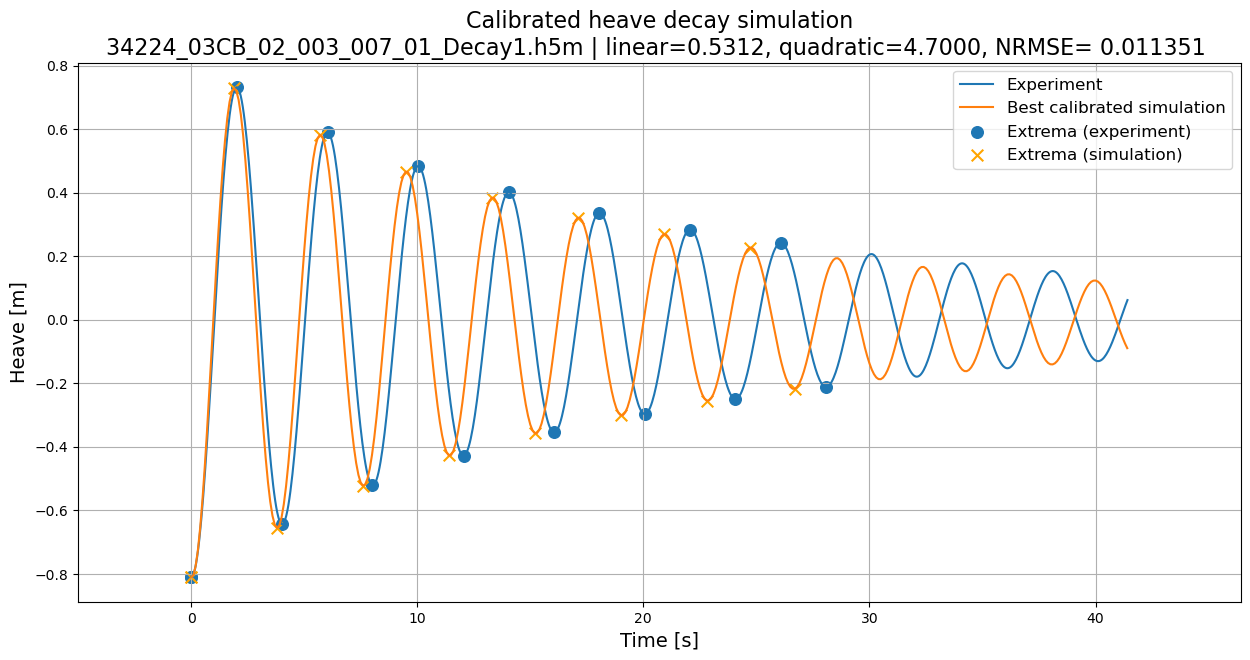

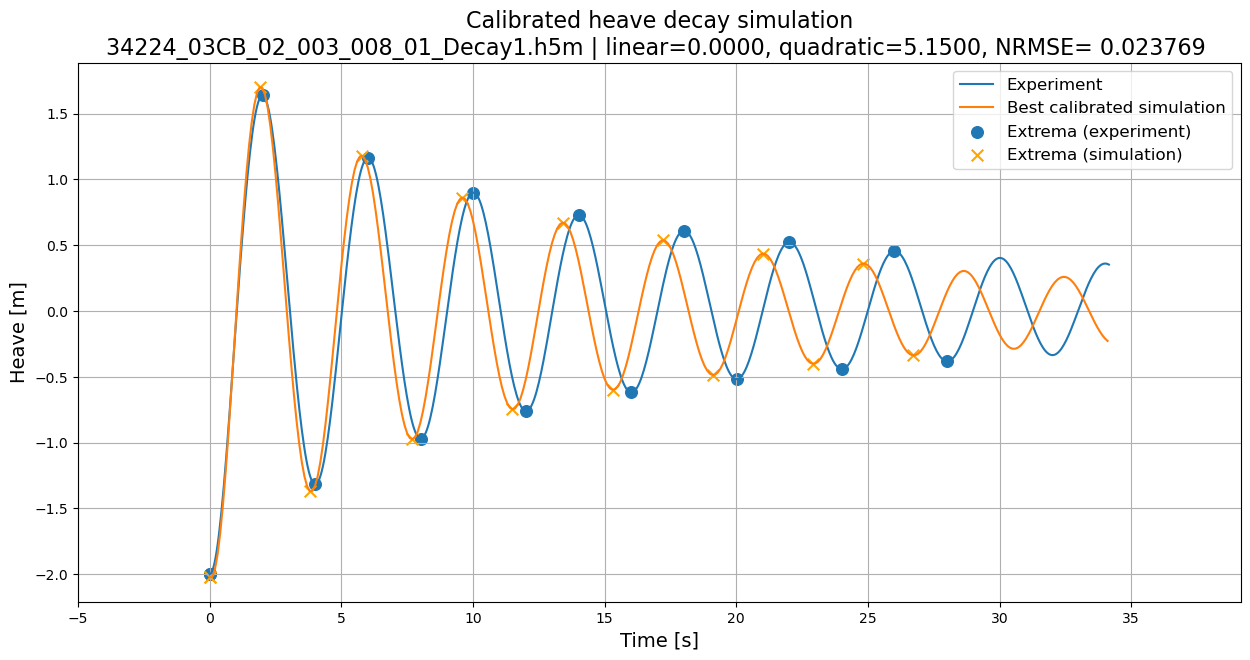

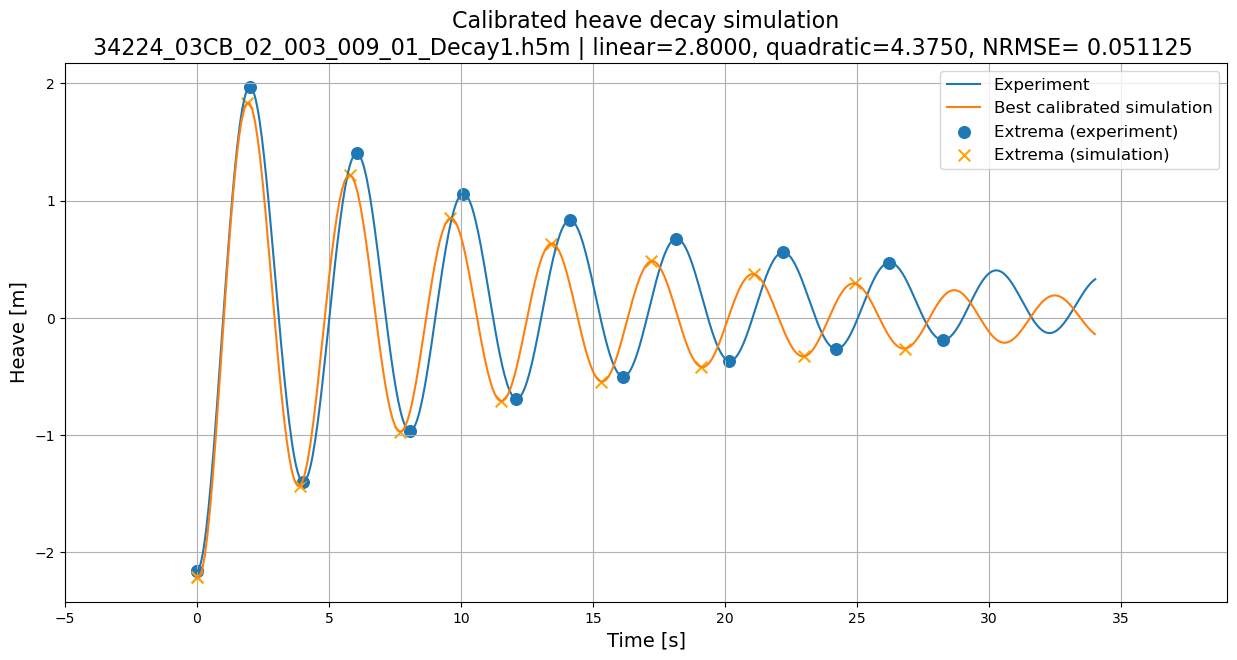

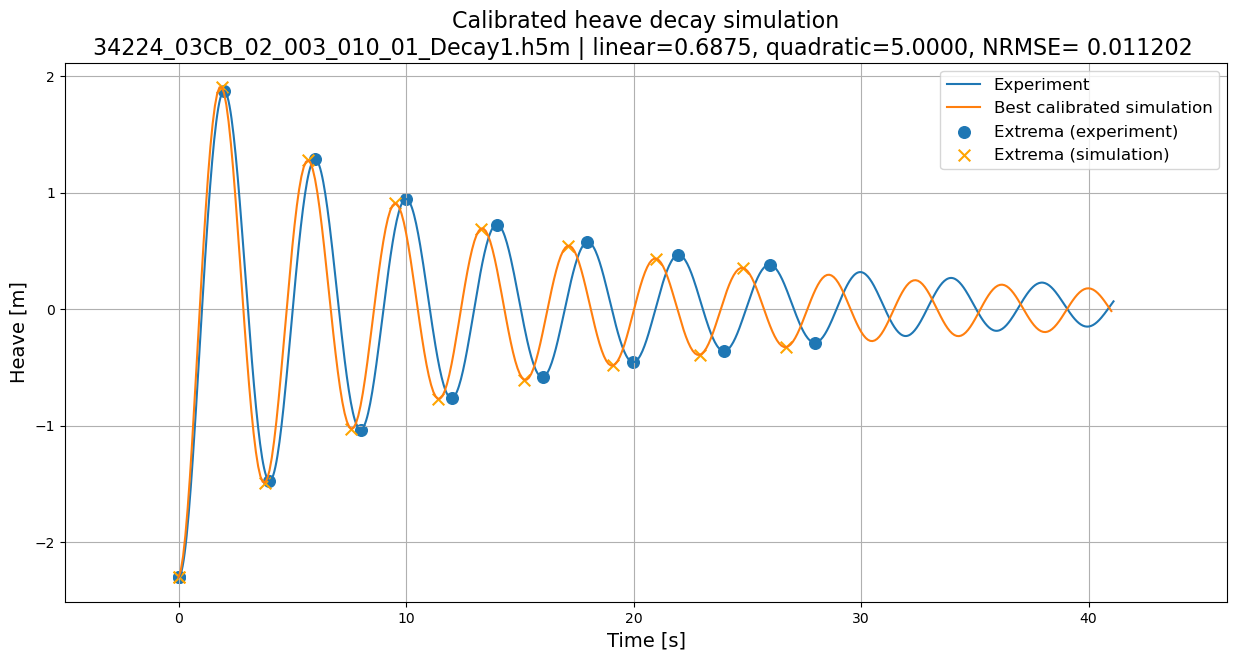

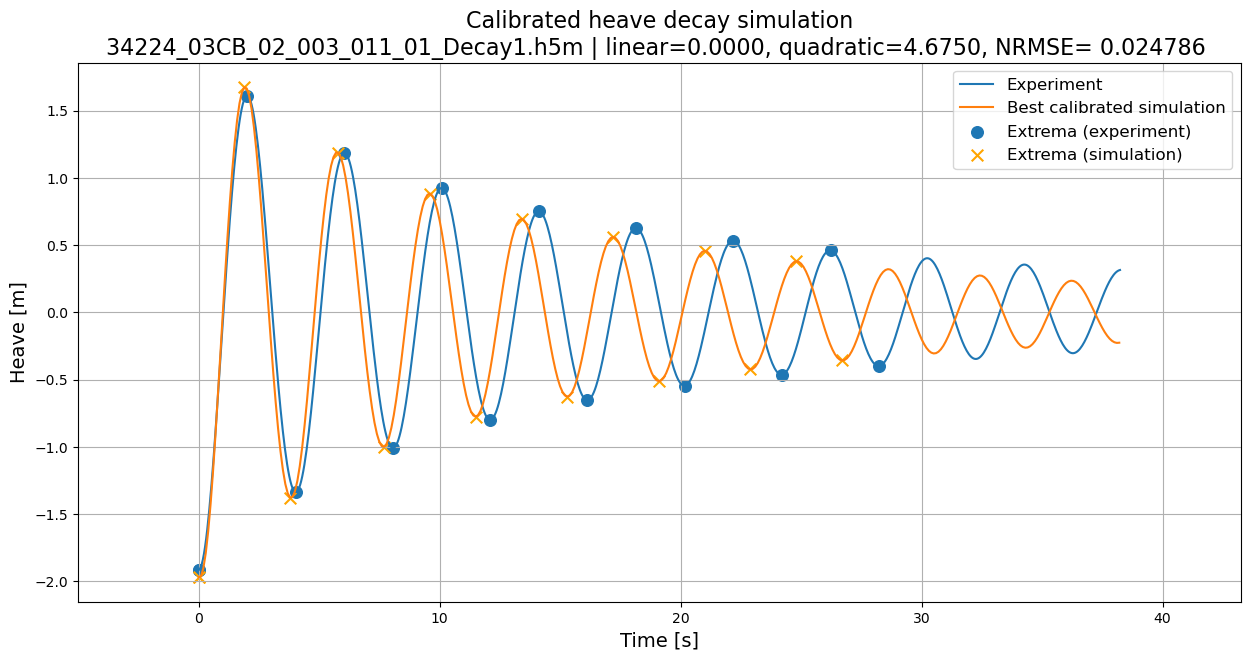

In [9]:
if save_plots:
    plot_output_dir.mkdir(parents=True, exist_ok=True)

for result in batch_results:
    exp_info = result["exp_info"]
    best = result["best_fine"]

    t_decay = exp_info["t_decay"]
    z_decay = exp_info["z_decay"]

    t_sim_shift = best["t_sim_shift"]
    z_sim_shift = best["z_sim_shift"]

    t_max = t_decay[-1]
    mask_sim = t_sim_shift <= t_max
    t_sim_plot = t_sim_shift[mask_sim]
    z_sim_plot = z_sim_shift[mask_sim]

    plt.figure(figsize=(15, 7))
    plt.plot(t_decay, z_decay, label="Experiment")
    plt.plot(t_sim_plot, z_sim_plot, label="Best calibrated simulation")

    plt.scatter(exp_info["t_ref_troughs"], exp_info["z_ref_troughs"], s=70, label="Extrema (experiment)", color = "#1f77b4" )
    plt.scatter(best["t_sim_ext_troughs"], best["z_sim_ext_troughs"], s=70, marker="x", label="Extrema (simulation)", color="orange")
    plt.scatter(exp_info["t_ref_peaks"], exp_info["z_ref_peaks"], s=70, color = "#1f77b4")
    plt.scatter(best["t_sim_ext_peaks"], best["z_sim_ext_peaks"], s=70, marker="x", color="orange")

    fname = Path(exp_info["exp_path"]).name
    plt.xlabel("Time [s]", fontsize=LABEL_SIZE)
    plt.ylabel("Heave [m]", fontsize=LABEL_SIZE)
    plt.title(
        "Calibrated heave decay simulation\n"
        f"{fname} | linear={best['c_lin']:.4f}, quadratic={best['c_quad']:.4f}, "
        f"NRMSE= {best['score']:.6f} ",
        fontsize=TITLE_SIZE
    )
    plt.xlim(-5, t_decay[-1] + 5)
    plt.legend(fontsize=TICK_SIZE)

    if save_plots:
        safe_name = Path(exp_info["exp_path"]).stem.replace(" ", "_")
        plt.savefig(plot_output_dir / f"{safe_name}_best_calibration.png", dpi=150, bbox_inches="tight")

    plt.show()


## Samenvatting van beste gecalibreerde coëfficiënten

In [10]:
summary_rows = []

for result in batch_results:
    exp_info = result["exp_info"]
    best_coarse = result["best_coarse"]
    best_mid = result["best_mid"]
    best_fine = result["best_fine"]

    summary_rows.append({
        "bestand": Path(exp_info["exp_path"]).name,
        "pad": exp_info["exp_path"],
        "A0_signed [m]": exp_info["A0_signed"],
        "extremum_number": exp_info["extremum_number"],
        "coarse_lin": best_coarse["c_lin"],
        "coarse_quad": best_coarse["c_quad"],
        "coarse_score": best_coarse["score"],
        "mid_lin": best_mid["c_lin"],
        "mid_quad": best_mid["c_quad"],
        "mid_score": best_mid["score"],
        "fine_lin": best_fine["c_lin"],
        "fine_quad": best_fine["c_quad"],
        "fine_score_total": best_fine["score"],
        "fine_score_peaks": best_fine["score_peaks"],
        "fine_score_troughs": best_fine["score_troughs"],
        "n_peaks_used": best_fine["n_peaks_used"],
        "n_troughs_used": best_fine["n_troughs_used"],
        "period_exp [s]": result["T_exp"],
        "period_sim [s]": result["T_sim"],
    })

df_summary = pd.DataFrame(summary_rows)
df_summary = df_summary.sort_values("bestand").reset_index(drop=True)

print("Aantal succesvol verwerkt:", len(df_summary))
display(df_summary)


Aantal succesvol verwerkt: 5


,bestand,pad,A0_signed [m],extremum_number,coarse_lin,coarse_quad,coarse_score,mid_lin,mid_quad,mid_score,fine_lin,fine_quad,fine_score_total,fine_score_peaks,fine_score_troughs,n_peaks_used,n_troughs_used,period_exp [s],period_sim [s]
0,34224_03CB_02_003_007_01_Decay1.h5m,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,-1.002898,1,0.0,5.0,0.012122,0.3125,5.000,0.011771,0.53125,4.700,0.011351,0.016101,0.006600,8,8,4.008469,3.81
1,34224_03CB_02_003_008_01_Decay1.h5m,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,-3.705561,1,0.0,5.0,0.024879,0.0000,5.000,0.024879,0.00000,5.150,0.023769,0.031353,0.016186,8,8,4.001432,3.81
2,34224_03CB_02_003_009_01_Decay1.h5m,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,-4.272154,1,0.0,5.0,0.053050,2.5000,4.375,0.051232,2.80000,4.375,0.051125,0.080199,0.022051,8,8,4.033124,3.81
3,34224_03CB_02_003_010_01_Decay1.h5m,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,-4.710989,1,0.0,5.0,0.018143,0.6250,5.000,0.011338,0.68750,5.000,0.011202,0.012411,0.009993,8,8,3.993456,3.81
4,34224_03CB_02_003_011_01_Decay1.h5m,C:\Users\verav\Desktop\Studie\Afstuderen\Decay...,-3.308130,1,0.0,5.0,0.032358,0.3125,4.375,0.028834,0.00000,4.675,0.024786,0.031003,0.018569,8,8,4.028160,3.81


## Eventuele fouten

In [11]:

df_failed = pd.DataFrame(failed_files)
display(df_failed)


""


## Optioneel: samenvatting exporteren naar Excel

In [12]:

save_summary_excel = True
summary_excel_path = Path("Heave_fixedwithdeck_summary_V2.xlsx")

if save_summary_excel and len(df_summary) > 0:
    df_summary.to_excel(summary_excel_path, index=False)
    print(f"Samenvatting opgeslagen naar: {summary_excel_path.resolve()}")
else:
    print("Excel-export staat uit of er is geen samenvatting beschikbaar.")


Samenvatting opgeslagen naar: C:\Users\verav\Desktop\Studie\Afstuderen\PHASE2_v2\PHASE2_V2\Decaytest_heave_fixed with deck\Heave_fixedwithdeck_summary_V2.xlsx
